## 1. Setup and paths

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from pathlib import Path

np.random.seed(42)
sns.set_theme(style="whitegrid")

# Project root: repo root (works when run from repo root or from notebooks/)
PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
# Data roots (Sensor Logger: each recording = folder with Accelerometer.csv, Gyroscope.csv)
RAW_DATA_DIRS = ["data/raw/raw_data", "data/raw/raw_data2"]
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Windowing & resampling (justified below) ---
TARGET_HZ = 50   # Common sampling rate after harmonization
WINDOW_SEC = 1.0 # Window length in seconds
STEP_SEC = 0.5   # Step (50% overlap)

print("Project root:", PROJECT_ROOT)
print("Processed output:", OUTPUT_DIR)

Project root: /Users/jade/Hidden_Markov_Models
Processed output: /Users/jade/Hidden_Markov_Models/data/processed


## 2. Discover recordings and infer activity labels

In [2]:
def get_activity_from_folder_name(folder_name):
    """Normalize folder name to one of: standing, walking, jumping, still."""
    base = os.path.basename(folder_name).lower()
    # Remove trailing date/time (e.g. -2026-03-03_08-40-50) and numbers
    base = re.sub(r"-\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}.*", "", base)
    base = re.sub(r"\s+", "_", base)
    if base.startswith("standing"): return "standing"
    if base.startswith("walking"): return "walking"
    if base.startswith("jumping"): return "jumping"
    if base.startswith("still"): return "still"
    return None

def list_recording_folders():
    """List (folder_path, activity) for each recording. Skips nested folders (e.g. still_5 inside jumping_6)."""
    records = []
    for data_dir in RAW_DATA_DIRS:
        root = PROJECT_ROOT / data_dir
        if not root.exists():
            continue
        for name in sorted(os.listdir(root)):
            path = root / name
            if not path.is_dir():
                continue
            # Only top-level recording folders (each has Accel + Gyro CSVs)
            acc = path / "Accelerometer.csv"
            gyr = path / "Gyroscope.csv"
            if not acc.exists() or not gyr.exists():
                continue
            activity = get_activity_from_folder_name(name)
            if activity is None:
                continue
            records.append((str(path), activity, data_dir))
    return records

recordings = list_recording_folders()
print(f"Total recordings: {len(recordings)}")
for act in ["standing", "walking", "jumping", "still"]:
    n = sum(1 for _, a, _ in recordings if a == act)
    print(f"  {act}: {n}")

Total recordings: 50
  standing: 13
  walking: 12
  jumping: 12
  still: 13


## 3. Load one recording: merge Accelerometer and Gyroscope

In [3]:
def load_one_recording(folder_path):
    """Load Accelerometer and Gyroscope, merge on seconds_elapsed. Returns DataFrame with time index."""
    path = Path(folder_path)
    acc = pd.read_csv(path / "Accelerometer.csv")
    gyr = pd.read_csv(path / "Gyroscope.csv")
    acc = acc.rename(columns={"x": "acc_x", "y": "acc_y", "z": "acc_z"})
    gyr = gyr.rename(columns={"x": "gyr_x", "y": "gyr_y", "z": "gyr_z"})
    acc = acc[["seconds_elapsed", "acc_x", "acc_y", "acc_z"]].drop_duplicates(subset=["seconds_elapsed"])
    gyr = gyr[["seconds_elapsed", "gyr_x", "gyr_y", "gyr_z"]].drop_duplicates(subset=["seconds_elapsed"])
    df = pd.merge(acc, gyr, on="seconds_elapsed", how="inner")
    df = df.sort_values("seconds_elapsed").reset_index(drop=True)
    df["time"] = df["seconds_elapsed"]
    df = df.set_index("time")
    return df

# Quick test
sample_path = recordings[0][0]
sample_df = load_one_recording(sample_path)
print("Sample recording shape:", sample_df.shape)
print(sample_df.head())

Sample recording shape: (1057, 7)
          seconds_elapsed     acc_x     acc_y     acc_z     gyr_x     gyr_y  \
time                                                                          
0.079177         0.079177  0.306734 -0.272964 -0.232869 -0.006184 -0.143767   
0.089175         0.089175  0.255809 -0.271763 -0.176157  0.029789 -0.154137   
0.099173         0.099173  0.123803 -0.266145 -0.120043  0.030607 -0.146607   
0.109171         0.109171 -0.011775 -0.259245 -0.100614  0.023972 -0.108839   
0.119169         0.119169 -0.127590 -0.305385 -0.184352  0.028648 -0.063430   

             gyr_z  
time                
0.079177  0.048352  
0.089175  0.050756  
0.099173  0.034759  
0.109171  0.006692  
0.119169 -0.033764  


## 4. Sampling rate: compute per recording and harmonize


In [4]:
def estimate_sampling_rate(df):
    """Estimate Hz from consecutive time differences."""
    t = df.index.values
    if len(t) < 2:
        return np.nan
    dt = np.diff(t)
    dt_median = np.median(dt)
    if dt_median <= 0:
        return np.nan
    return 1.0 / dt_median

def resample_to_target(df, target_hz=TARGET_HZ):
    """Resample to target_hz using linear interpolation (index = seconds)."""
    duration = df.index.max() - df.index.min()
    if duration <= 0:
        return df
    n_samples = int(round(duration * target_hz))
    new_index = np.linspace(df.index.min(), df.index.max(), n_samples)
    return df.reindex(df.index.union(new_index)).interpolate(method="linear").loc[new_index]

# Report sampling rate per recording (for report table)
rates = []
for folder_path, activity, source in recordings:
    df = load_one_recording(folder_path)
    hz = estimate_sampling_rate(df)
    duration = df.index.max() - df.index.min() if len(df) > 1 else 0
    rates.append({"folder": Path(folder_path).name, "activity": activity, "source": source, "hz": hz, "duration_sec": duration})

rates_df = pd.DataFrame(rates)
print("Sampling rate (Hz) per recording (use this for your report table):")
print(rates_df.groupby(["source", "activity"]).agg({"hz": ["min", "max", "mean"], "duration_sec": "sum"}).round(2))
print("\nTotal duration per activity (seconds):")
print(rates_df.groupby("activity")["duration_sec"].sum().round(1))

Sampling rate (Hz) per recording (use this for your report table):
                        hz                 duration_sec
                       min     max    mean          sum
source    activity                                     
raw_data  jumping   100.02  100.02  100.02        63.39
          standing  100.02  100.02  100.02        63.82
          still     100.02  100.03  100.03        75.43
          walking   100.02  100.02  100.02        62.54
raw_data2 jumping    99.71   99.71   99.71        59.64
          standing   99.70   99.72   99.71        69.72
          still      99.71   99.72   99.72        59.71
          walking    99.70   99.70   99.70        59.80

Total duration per activity (seconds):
activity
jumping     123.0
standing    133.5
still       135.1
walking     122.3
Name: duration_sec, dtype: float64


## 5. Windowing: rationale and implementation



In [5]:
def build_windows(df, window_sec=WINDOW_SEC, step_sec=STEP_SEC, target_hz=TARGET_HZ):
    """Split resampled DataFrame into overlapping windows. Returns list of (start_time, end_time, slice_df)."""
    df = resample_to_target(df, target_hz)
    t = df.index.values
    if len(t) < 2:
        return []
    window_samples = int(round(window_sec * target_hz))
    step_samples = int(round(step_sec * target_hz))
    if step_samples < 1:
        step_samples = 1
    windows = []
    start = 0
    while start + window_samples <= len(df):
        end = start + window_samples
        w = df.iloc[start:end]
        windows.append((w.index.min(), w.index.max(), w))
        start += step_samples
    return windows

# Test on one recording
test_df = load_one_recording(recordings[0][0])
test_df = resample_to_target(test_df, TARGET_HZ)
windows = build_windows(test_df, WINDOW_SEC, STEP_SEC, TARGET_HZ)
print(f"Recording length: {len(test_df)} samples ({test_df.index.max() - test_df.index.min():.2f} s)")
print(f"Number of windows: {len(windows)}")

Recording length: 528 samples (10.56 s)
Number of windows: 20


## 6. Feature extraction



In [6]:
SIGNAL_COLS = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]

def time_domain_features(w):
    """Compute time-domain features per window (w = DataFrame slice)."""
    out = {}
    for col in SIGNAL_COLS:
        out[f"mean_{col}"] = w[col].mean()
        out[f"var_{col}"] = w[col].var()
        out[f"std_{col}"] = w[col].std()
    # SMA for acc and gyr separately (typical in HAR)
    out["sma_acc"] = (w[["acc_x", "acc_y", "acc_z"]].abs().sum(axis=1)).mean()
    out["sma_gyr"] = (w[["gyr_x", "gyr_y", "gyr_z"]].abs().sum(axis=1)).mean()
    # Correlations between axes (accelerometer)
    out["corr_acc_xy"] = w[["acc_x", "acc_y"]].corr().iloc[0, 1]
    out["corr_acc_xz"] = w[["acc_x", "acc_z"]].corr().iloc[0, 1]
    out["corr_acc_yz"] = w[["acc_y", "acc_z"]].corr().iloc[0, 1]
    return out

def frequency_domain_features(w, cols=None):
    """FFT-derived features. cols: which columns to use (default: acc_x for dominant freq and energy)."""
    if cols is None:
        cols = ["acc_x", "acc_y", "acc_z"]
    out = {}
    for col in cols:
        x = w[col].values
        n = len(x)
        if n < 4:
            out[f"dom_freq_{col}"] = 0.0
            out[f"spectral_energy_{col}"] = 0.0
            continue
        yf = fft(x)
        freqs = fftfreq(n, 1.0 / TARGET_HZ)
        pos_mask = freqs > 0
        freqs_pos = freqs[pos_mask]
        mag = np.abs(yf[pos_mask])
        if len(mag) == 0:
            out[f"dom_freq_{col}"] = 0.0
            out[f"spectral_energy_{col}"] = 0.0
            continue
        idx_max = np.argmax(mag)
        out[f"dom_freq_{col}"] = freqs_pos[idx_max]
        # Spectral energy: sum of squared magnitudes in 0.5--5 Hz (typical for human motion)
        band = (freqs_pos >= 0.5) & (freqs_pos <= 5.0)
        out[f"spectral_energy_{col}"] = np.sum(mag[band] ** 2)
    return out

def extract_features_for_window(w):
    """One feature vector per window."""
    feats = time_domain_features(w)
    feats.update(frequency_domain_features(w, cols=["acc_x", "acc_y", "acc_z"]))
    return feats

In [9]:
# Build ordered feature names (for consistent columns)
def get_feature_names():
    w = pd.DataFrame({c: [0.0] * 50 for c in SIGNAL_COLS})
    f = extract_features_for_window(w)
    return list(f.keys())

FEATURE_NAMES = get_feature_names()
print("Number of features:", len(FEATURE_NAMES))
print("Time-domain (mean/var/std/sma/corr):", [n for n in FEATURE_NAMES if "dom_freq" not in n and "spectral_energy" not in n])
print("Frequency-domain (FFT):", [n for n in FEATURE_NAMES if "dom_freq" in n or "spectral_energy" in n])

Number of features: 29
Time-domain (mean/var/std/sma/corr): ['mean_acc_x', 'var_acc_x', 'std_acc_x', 'mean_acc_y', 'var_acc_y', 'std_acc_y', 'mean_acc_z', 'var_acc_z', 'std_acc_z', 'mean_gyr_x', 'var_gyr_x', 'std_gyr_x', 'mean_gyr_y', 'var_gyr_y', 'std_gyr_y', 'mean_gyr_z', 'var_gyr_z', 'std_gyr_z', 'sma_acc', 'sma_gyr', 'corr_acc_xy', 'corr_acc_xz', 'corr_acc_yz']
Frequency-domain (FFT): ['dom_freq_acc_x', 'spectral_energy_acc_x', 'dom_freq_acc_y', 'spectral_energy_acc_y', 'dom_freq_acc_z', 'spectral_energy_acc_z']


## 7. Normalization (Z-score)



In [10]:
from sklearn.preprocessing import StandardScaler

# We'll fit scaler on training feature matrix later; placeholder here.
def normalize_features(X_train, X_test=None):
    """Z-score: fit on X_train, transform train and (if provided) test."""
    scaler = StandardScaler()
    X_train_n = scaler.fit_transform(X_train)
    if X_test is not None:
        X_test_n = scaler.transform(X_test)
        return X_train_n, X_test_n, scaler
    return X_train_n, None, scaler

## 8. Build full dataset: observation sequences and labels



In [11]:
ACTIVITY_TO_ID = {"standing": 0, "walking": 1, "jumping": 2, "still": 3}
ID_TO_ACTIVITY = {v: k for k, v in ACTIVITY_TO_ID.items()}

def process_all_recordings(recordings_list, window_sec=WINDOW_SEC, step_sec=STEP_SEC, target_hz=TARGET_HZ):
    """Returns: list of (observation_sequence, label_sequence) per recording."""
    all_sequences = []  # list of (X, y) where X = (n_windows, n_features), y = (n_windows,)
    for folder_path, activity, _ in recordings_list:
        df = load_one_recording(folder_path)
        windows = build_windows(df, window_sec, step_sec, target_hz)
        if not windows:
            continue
        rows = []
        for _, _, w in windows:
            feats = extract_features_for_window(w)
            rows.append([feats[k] for k in FEATURE_NAMES])
        X = np.array(rows)
        y = np.full(len(rows), ACTIVITY_TO_ID[activity])
        all_sequences.append((X, y, activity, folder_path))
    return all_sequences

all_sequences = process_all_recordings(recordings)
print(f"Total recordings processed: {len(all_sequences)}")
total_windows = sum(X.shape[0] for X, y, _, _ in all_sequences)
print(f"Total windows: {total_windows}")

Total recordings processed: 50
Total windows: 946


In [12]:
# Train/test split: hold out 2 recordings (e.g. one per activity or random) for unseen evaluation
def train_test_split_recordings(sequences, test_count=2, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(sequences))
    rng.shuffle(indices)
    test_idx = set(indices[:test_count])
    train_seq = [s for i, s in enumerate(sequences) if i not in test_idx]
    test_seq = [s for i, s in enumerate(sequences) if i in test_idx]
    return train_seq, test_seq

train_sequences, test_sequences = train_test_split_recordings(all_sequences, test_count=2)
print(f"Train recordings: {len(train_sequences)}, Test recordings: {len(test_sequences)}")
if test_sequences:
    print("Test recording activities:", [s[2] for s in test_sequences])

Train recordings: 48, Test recordings: 2
Test recording activities: ['jumping', 'jumping']


In [13]:
# Stack train/test and normalize
def stack_sequences(seq_list):
    X_list = [s[0] for s in seq_list]
    y_list = [s[1] for s in seq_list]
    return np.vstack(X_list), np.concatenate(y_list)

X_train_full, y_train_full = stack_sequences(train_sequences)
if test_sequences:
    X_test_full, y_test_full = stack_sequences(test_sequences)
else:
    X_test_full = np.empty((0, len(FEATURE_NAMES)))
    y_test_full = np.array([])

X_train_n, X_test_n, scaler = normalize_features(X_train_full, X_test_full if len(X_test_full) > 0 else None)

print("Train shape:", X_train_n.shape)
print("Test shape:", X_test_n.shape if X_test_n is not None else (0, X_train_n.shape[1]))

# Save scaler and feature names for Part 2
import pickle
with open(OUTPUT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump({"scaler": scaler, "feature_names": FEATURE_NAMES, "activity_to_id": ACTIVITY_TO_ID}, f)
np.save(OUTPUT_DIR / "feature_names.npy", np.array(FEATURE_NAMES))
np.save(OUTPUT_DIR / "activity_to_id.npy", np.array(list(ACTIVITY_TO_ID.items())))

Train shape: (909, 29)
Test shape: (37, 29)


In [14]:
# Export observation sequences for Part 2: list of (X_normalized) per recording (train and test)
def normalized_sequences_for_hmm(train_sequences, test_sequences, scaler):
    train_obs = []
    train_labels = []
    for X, y, _, _ in train_sequences:
        X_n = scaler.transform(X)
        train_obs.append(X_n)
        train_labels.append(y)
    test_obs = []
    test_labels = []
    for X, y, _, _ in test_sequences:
        X_n = scaler.transform(X)
        test_obs.append(X_n)
        test_labels.append(y)
    return train_obs, train_labels, test_obs, test_labels

train_obs, train_labels, test_obs, test_labels = normalized_sequences_for_hmm(train_sequences, test_sequences, scaler)

with open(OUTPUT_DIR / "train_observation_sequences.pkl", "wb") as f:
    pickle.dump({"sequences": train_obs, "labels": train_labels}, f)
with open(OUTPUT_DIR / "test_observation_sequences.pkl", "wb") as f:
    pickle.dump({"sequences": test_obs, "labels": test_labels}, f)

print("Saved train/test observation sequences and scaler to", OUTPUT_DIR)

Saved train/test observation sequences and scaler to /Users/jade/Hidden_Markov_Models/data/processed


## 9. Visualizations of sample data 


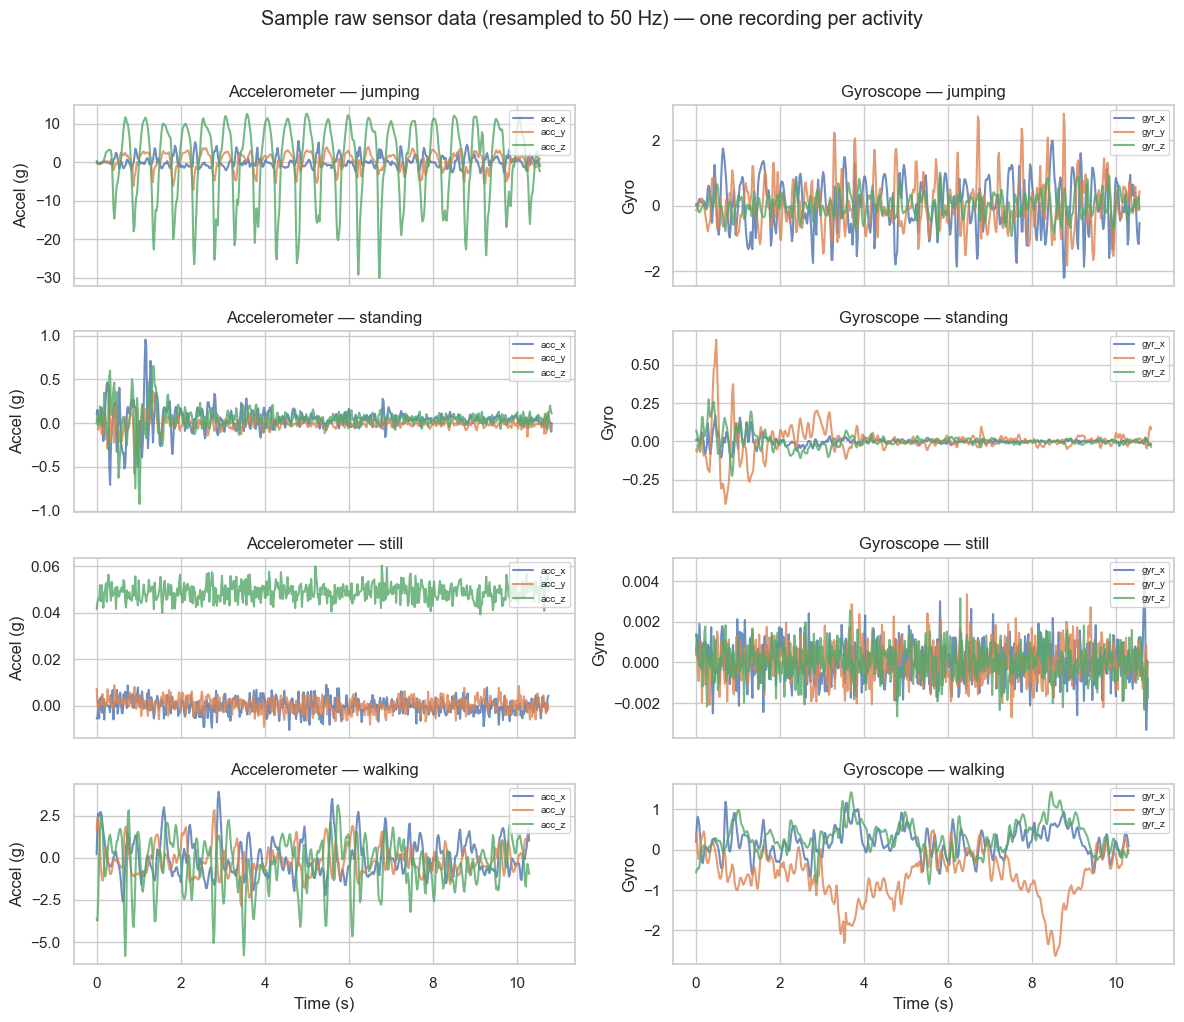

In [15]:
# Pick one recording per activity for plotting
sample_per_activity = {}
for folder_path, activity, _ in recordings:
    if activity not in sample_per_activity:
        sample_per_activity[activity] = (folder_path, activity)
    if len(sample_per_activity) == 4:
        break

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
for row, (activity, (folder_path, _)) in enumerate(sample_per_activity.items()):
    df = load_one_recording(folder_path)
    df = resample_to_target(df, TARGET_HZ)
    t = df.index.values - df.index.min()
    axes[row, 0].plot(t, df["acc_x"], label="acc_x", alpha=0.8)
    axes[row, 0].plot(t, df["acc_y"], label="acc_y", alpha=0.8)
    axes[row, 0].plot(t, df["acc_z"], label="acc_z", alpha=0.8)
    axes[row, 0].set_ylabel("Accel (g)")
    axes[row, 0].set_title(f"Accelerometer — {activity}")
    axes[row, 0].legend(loc="upper right", fontsize=7)
    axes[row, 1].plot(t, df["gyr_x"], label="gyr_x", alpha=0.8)
    axes[row, 1].plot(t, df["gyr_y"], label="gyr_y", alpha=0.8)
    axes[row, 1].plot(t, df["gyr_z"], label="gyr_z", alpha=0.8)
    axes[row, 1].set_ylabel("Gyro")
    axes[row, 1].set_title(f"Gyroscope — {activity}")
    axes[row, 1].legend(loc="upper right", fontsize=7)
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.suptitle("Sample raw sensor data (resampled to 50 Hz) — one recording per activity", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_data_per_activity.png", dpi=150, bbox_inches="tight")
plt.show()

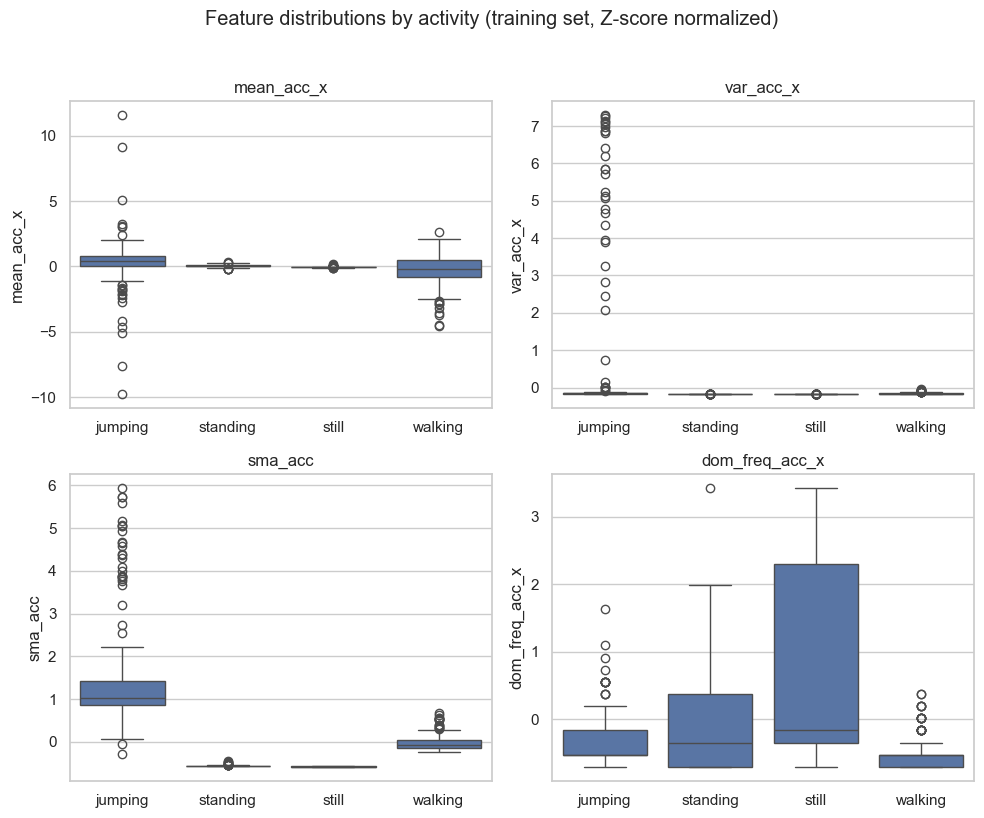

In [16]:
# Feature distributions per activity (training set) — shows that features discriminate activities
train_X, train_y = stack_sequences(train_sequences)
train_X_n, _, _ = normalize_features(train_X)
feat_df = pd.DataFrame(train_X_n, columns=FEATURE_NAMES)
feat_df["activity"] = [ID_TO_ACTIVITY[i] for i in train_y]

# Plot a subset: mean acc_x, var acc_x, sma_acc, dom_freq_acc_x
subset = ["mean_acc_x", "var_acc_x", "sma_acc", "dom_freq_acc_x"]
subset = [c for c in subset if c in feat_df.columns]
if len(subset) >= 2:
    fig2, ax2 = plt.subplots(2, 2, figsize=(10, 8))
    ax2 = ax2.ravel()
    for i, col in enumerate(subset[:4]):
        sns.boxplot(data=feat_df, x="activity", y=col, ax=ax2[i])
        ax2[i].set_title(col)
        ax2[i].set_xlabel("")
    plt.suptitle("Feature distributions by activity (training set, Z-score normalized)", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_distributions_by_activity.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10. Save cleaned dataset 

Save CSV with one row per window: `file_id`, `activity`, `t_start`, `t_end`, and all feature columns (normalized). T

In [17]:
rows = []
for folder_path, activity, _ in recordings:
    df = load_one_recording(folder_path)
    windows = build_windows(df, WINDOW_SEC, STEP_SEC, TARGET_HZ)
    for t_start, t_end, w in windows:
        feats = extract_features_for_window(w)
        row = {"file": Path(folder_path).name, "activity": activity, "t_start": t_start, "t_end": t_end}
        row.update(feats)
        rows.append(row)

full_df = pd.DataFrame(rows)
feature_cols = [c for c in full_df.columns if c not in ("file", "activity", "t_start", "t_end")]
full_df["activity_id"] = full_df["activity"].map(ACTIVITY_TO_ID)
# Normalize features (fit on full - for export only; Part 2 uses train-fit scaler)
scaler_export = StandardScaler()
full_df[feature_cols] = scaler_export.fit_transform(full_df[feature_cols])
full_df.to_csv(OUTPUT_DIR / "cleaned_labeled_windows.csv", index=False)
print("Saved", len(full_df), "rows to", OUTPUT_DIR / "cleaned_labeled_windows.csv")
print("Activities:", full_df["activity"].value_counts().to_dict())

Saved 946 rows to /Users/jade/Hidden_Markov_Models/data/processed/cleaned_labeled_windows.csv
Activities: {'still': 250, 'standing': 245, 'walking': 226, 'jumping': 225}
